In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
df = pd.read_csv("jp_morgan.csv")
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,3,CUST2412,ACC80131,Loan,Withdrawal,Personal Loan,Firm C,West,Manager 3,06-08-2023,33759.69057,126486.40830,0.225824,611,89
1,32,CUST1467,ACC74631,Current,Withdrawal,Home Loan,Firm D,North,Manager 2,08-11-2023,69319.19933,24834.76291,0.335717,817,174
2,9,CUST2699,ACC39482,Loan,Withdrawal,Credit Card,Firm D,West,Manager 4,15-05-2024,42831.48483,123007.43530,0.572453,332,31
3,42,CUST9535,ACC82947,Current,Withdrawal,Home Loan,Firm A,South,Manager 4,30-04-2023,70903.79697,73073.64225,0.571993,626,92
4,166,CUST7459,ACC39500,Credit,Payment,Home Loan,Firm D,South,Manager 4,16-02-2023,21948.97355,113405.32820,0.380675,411,13


In [3]:
# Task 1:Data Cleaning and Formatting 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


In [5]:
df.describe()

,TransactionID,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
count,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,101.96125,51086.624542,74528.005025,0.473350,576.303750,123.566250
std,58.27147,29076.621451,32608.264579,0.245104,160.816133,66.426755
min,1.00000,-60979.073480,-13812.693060,-0.368537,304.000000,6.000000
25%,49.00000,32589.042120,53547.221090,0.305702,433.000000,67.000000
50%,104.00000,50307.224210,73736.442995,0.461838,573.000000,123.000000
75%,155.25000,70179.479290,95584.413473,0.634402,722.000000,181.000000
max,199.00000,147447.295100,183836.933800,1.345638,849.000000,239.000000


In [6]:
df.isnull().sum()

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

In [7]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'],dayfirst=True)
df = df.sort_values(by='TransactionDate')

In [8]:
df['TransactionType'] = df['TransactionType'].str.strip()
df['AccountType'] = df['AccountType'].str.strip()

In [9]:
# task 2: Descriptive Transactional Analysis

In [10]:
# monthly summary

In [11]:
df['Month'] = df['TransactionDate'].dt.to_period('M')

monthly_summary = df.groupby(['Month','TransactionType'])['TransactionAmount'].sum().unstack()
monthly_summary['Net'] = monthly_summary['Deposit'] - monthly_summary['Withdrawal']
monthly_summary.head()

TransactionType,Deposit,Payment,Transfer,Withdrawal,Net
Month,,,,,
2023-01,586442.42703,892403.329063,511503.904434,815781.122358,-229338.695328
2023-02,788091.35844,896472.509573,641396.528880,439855.688290,348235.670150
2023-03,568405.45070,621706.357696,439425.289570,845856.681975,-277451.231275
2023-04,593836.81001,712652.450490,519042.113963,883698.507661,-289861.697651
2023-05,729309.61573,633500.534446,818742.047450,415485.163630,313824.452100


In [12]:
# yearly summary

In [13]:
df['Year'] = df['TransactionDate'].dt.year

yearly_summary = df.groupby(['Year','TransactionType'])['TransactionAmount'].sum().unstack()
yearly_summary['Net'] = yearly_summary['Deposit'] - yearly_summary['Withdrawal']
yearly_summary.head()

TransactionType,Deposit,Payment,Transfer,Withdrawal,Net
Year,,,,,
2023,8.225787e+06,6.974170e+06,6.395137e+06,8.017619e+06,208167.620959
2024,2.238946e+06,3.100943e+06,2.711474e+06,3.205223e+06,-966276.250372


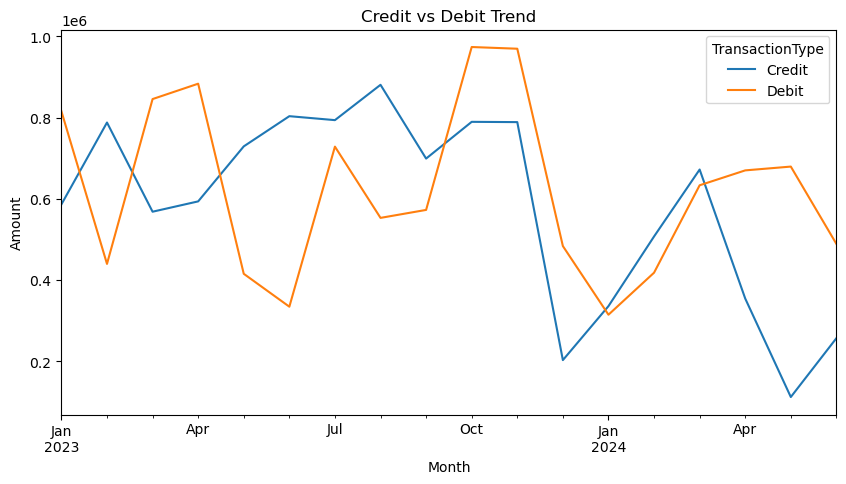

In [14]:
monthly_summary[['Deposit', 'Withdrawal']].rename(columns={
    'Deposit': 'Credit', 
    'Withdrawal': 'Debit'
}).plot(figsize=(10,5))
plt.title("Credit vs Debit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.show()

In [15]:
# Top & Bottom Accounts

In [16]:
account_flow = df.groupby('AccountID')['TransactionAmount'].sum()

top_accounts = account_flow.sort_values(ascending=False).head(10)
bottom_accounts = account_flow.sort_values().head(10)
top_accounts

AccountID
ACC42710    539494.876440
ACC45907    532556.635574
ACC81631    483854.558670
ACC32627    471468.023823
ACC18140    458219.210460
ACC95774    453488.129360
ACC55331    448188.410346
ACC29477    443067.484857
ACC29646    439477.177961
ACC22036    437626.170698
Name: TransactionAmount, dtype: float64

In [17]:
bottom_accounts

AccountID
ACC12334    15159.688345
ACC50439    24088.157284
ACC65144    30425.901148
ACC28305    32162.348245
ACC43771    32819.585640
ACC49180    37023.532950
ACC46655    37365.268690
ACC30146    42545.848430
ACC39482    42831.484830
ACC87006    42903.165440
Name: TransactionAmount, dtype: float64

In [18]:
# gap of two months

In [19]:
df = df.sort_values(['AccountID', 'TransactionDate'])

df['Prev_Date'] = df.groupby('AccountID')['TransactionDate'].shift(1)
df['Gap'] = (df['TransactionDate'] - df['Prev_Date']).dt.days

dormant_accounts = df[df['Gap'] > 60]['AccountID'].unique()

In [20]:
# task 3 : Customer Profile Building 

In [21]:
freq = df.groupby('AccountID').size()

In [22]:
# High: > 8 transactions
# Medium: 4-8
# Low: < 4

In [23]:
def activity_level(x):
    if x > 8:
        return "High"
    elif x >= 4:
        return "Medium"
    else:
        return "Low"

activity = freq.apply(activity_level)

In [24]:
# Average Balance & Volume

In [52]:
profile = df.groupby('AccountID').agg({
    'AccountBalance': 'mean',
    'TransactionAmount': 'sum'
}).rename(columns={
    'AccountBalance': 'Avg_Balance',
    'TransactionAmount': 'Total_Volume'
})

In [26]:
# Customer Profiles

In [27]:
# High Net Inflow

In [28]:
net_flow = df.groupby('AccountID').apply(
    lambda x: x[x['TransactionType']=='Deposit']['TransactionAmount'].sum() -
              x[x['TransactionType']=='Withdrawal']['TransactionAmount'].sum(),include_groups=False
)

high_inflow = net_flow[net_flow > net_flow.quantile(0.75)]

In [29]:
# High Frequency + Low Balance

In [30]:
high_freq_low_balance = profile[
    (profile['Avg_Balance'] < profile['Avg_Balance'].quantile(0.25)) &
    (freq > freq.quantile(0.75))
]

In [31]:
# Negative / Near Zero Balance

In [32]:
risky_balance = profile[profile['Avg_Balance'] <= 0]

In [33]:
# Task 4: Financial Risk Identification

In [34]:
# Large withdrawals

In [35]:
large_withdrawals = df[
    (df['TransactionType'] == 'Withdrawal') &
    (df['TransactionAmount'] > df['TransactionAmount'].quantile(0.95))
]
large_withdrawals

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Month,Year,Prev_Date,Gap
414,191,CUST1749,ACC29477,Current,Withdrawal,Credit Card,Firm A,North,Manager 2,2023-07-26,115702.80840,50193.67399,0.169155,813,209,2023-07,2023,2023-03-18,130.0
322,141,CUST5255,ACC40939,Loan,Withdrawal,Home Loan,Firm A,Central,Manager 3,2023-08-06,105938.61820,77344.76391,0.539436,379,233,2023-08,2023,NaT,NaN
175,132,CUST9962,ACC40952,Current,Withdrawal,Credit Card,Firm E,East,Manager 1,2023-10-06,114922.64320,78680.76419,0.965733,433,107,2023-10,2023,2023-01-02,277.0
138,71,CUST8279,ACC45907,Savings,Withdrawal,Savings Account,Firm D,North,Manager 4,2023-05-26,125896.51730,26843.02225,0.188484,515,206,2023-05,2023,2023-03-18,69.0
335,102,CUST1644,ACC55331,Credit,Withdrawal,Credit Card,Firm A,South,Manager 2,2023-03-08,116806.44680,47782.44387,0.231088,605,195,2023-03,2023,2023-02-23,13.0
80,130,CUST7388,ACC81631,Current,Withdrawal,Mutual Fund,Firm A,North,Manager 2,2023-06-18,98620.49477,35356.89429,0.726770,697,47,2023-06,2023,2023-06-17,1.0
9,158,CUST3041,ACC81631,Current,Withdrawal,Personal Loan,Firm A,East,Manager 2,2023-09-10,105066.72200,122057.46170,1.133565,510,28,2023-09,2023,2023-06-18,84.0
115,122,CUST8344,ACC99117,Credit,Withdrawal,Home Loan,Firm B,East,Manager 4,2024-01-29,129471.46560,73117.85560,0.186813,820,210,2024-01,2024,2024-01-12,17.0


In [36]:
 # Balance Volatility

In [37]:
volatility = df.groupby('AccountID')['AccountBalance'].std()

In [38]:
# IQR Method (Anomaly Detection)

In [39]:
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df['TransactionAmount'] < Q1 - 1.5*IQR) |
    (df['TransactionAmount'] > Q3 + 1.5*IQR)
]

In [40]:
# Task 5: Visualization

In [41]:
# Transaction Distribution

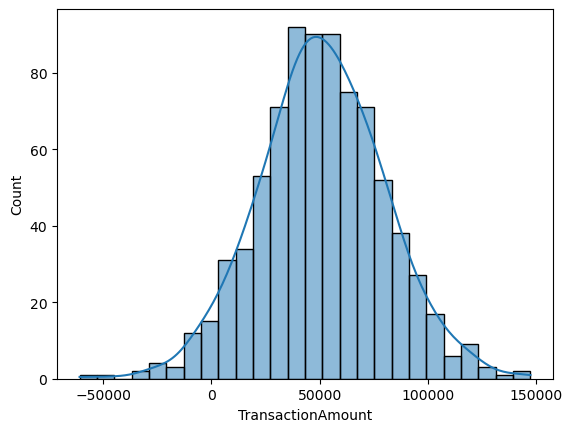

In [42]:
sns.histplot(df['TransactionAmount'], kde=True)
plt.show()

In [43]:
# Account Type Comparison

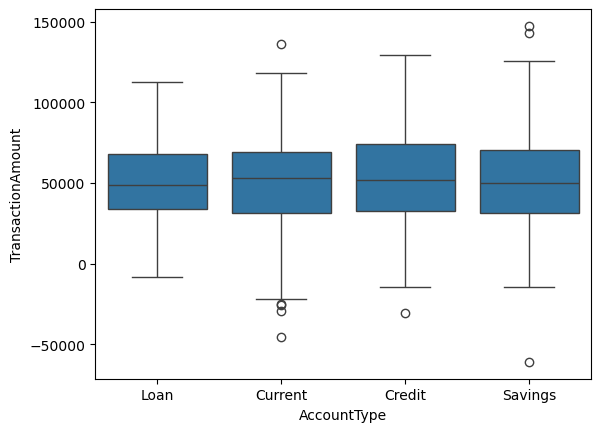

In [44]:
sns.boxplot(x='AccountType', y='TransactionAmount', data=df)
plt.show()

In [45]:
# Heatmap

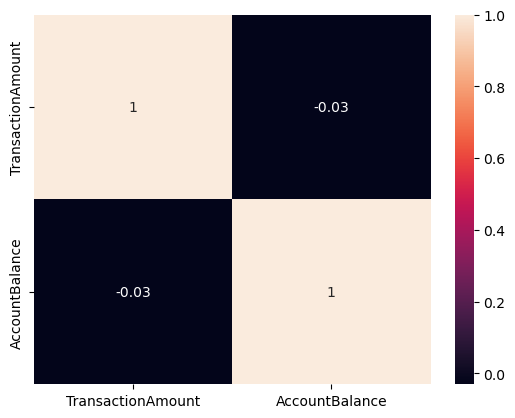

In [46]:
corr = df[['TransactionAmount', 'AccountBalance']].corr()
sns.heatmap(corr, annot=True)
plt.show()

In [47]:
# Task 6: Hypothesis Testing

In [48]:
# Define Groups

In [58]:
threshold = profile['Total_Volume'].median()

high_volume = profile[profile['Total_Volume'] > threshold]['Avg_Balance']
low_volume = profile[profile['Total_Volume'] <= threshold]['Avg_Balance']

In [ ]:
# Hypothesis Testing
# H0: No difference
# H1: High-volume accounts have higher balance

In [ ]:
# T-test

In [59]:
t_stat, p_value = stats.ttest_ind(high_volume, low_volume)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: -0.4331698271374088
P-value: 0.6653776293187159


In [60]:
if p_value < 0.05:
    print("Reject H0 → High-volume accounts have higher balances")
else:
    print("Fail to reject H0")

Fail to reject H0
